### A re-impelmetnation of `GSEA_Mitochondria_FullDEGList.ipynb` for this project's environment / conventions

In [188]:
# setup: imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

from utils.paths import DATA, FIGURES
from matplotlib.figure import Figure
from pathlib import Path

from adjustText import adjust_text

In [189]:
# initialize values & filepaths

THRESH_padj = 0.5
THRESH_lfc = 0.5
TOP_N_GENES = 25

DEG_FILEPATHS = [fp for fp in DATA.glob("deseq.results.*.txt")]
SEP = r"\s+"

TERMS_TO_EVALUATE = {
    "Oxidative Phosphorylation",
    "Xenobiotic Metabolism",
    "Fatty Acid Metabolism",
    "Reactive Oxygen Species Pathway",
    "Glycolysis",
    "heme Metabolism",
}

In [190]:
# utility functions


def preprocess_deseq_df(deseq_df: pd.DataFrame) -> pd.DataFrame:
    """
    preprocess deseq df in-place
    - remove dirty rows (non-kgCluster ids)
    - convert numeric columns from string to numeric dtypes
    """

    deseq_df = deseq_df[
        deseq_df["id"].str.startswith("kgCluster")
    ]  # filter bad columns
    deseq_df["symbol"] = (
        deseq_df["symbol"].astype(str).str.upper()
    )  # uppercase gene names

    base_numeric_cols = ["log2FcMAP", "lfcSE", "stat", "pvalue", "padj"]
    custom_numeric_cols = [
        col for col in deseq_df.columns if col.startswith("baseMean")
    ]

    for col in base_numeric_cols + custom_numeric_cols:
        deseq_df[col] = pd.to_numeric(deseq_df[col], errors="coerce")

    return deseq_df


def get_ranked_list(deseq_df: pd.DataFrame) -> pd.DataFrame:
    return (
        df[["symbol", "log2FcMAP"]]
        .set_index("symbol")
        .sort_values(by="log2FcMAP", ascending=False)
    )


def preprocess_volcano(
    deseq_df: pd.DataFrame,
    gene_set: set | pd.Index,
    padj_thresh: float,
    lfc_thresh: float,
) -> pd.DataFrame:
    """
    Returns a preprocessed slice of `deseq_df` with a significance column ready to plot in a volcano plot.

    :param deseq_df: The dataframe. Expects gene IDs to be dataframe index, not a column.
    :type deseq_df: pd.DataFramere
    :param gene_set: Set of genes to contribute to the volcano plot (usually those associated with a GO term)
    :type gene_set: set | pd.Index
    :param padj_thresh: The adjusted p-value threshold. Operates on column 'padj'. Strictly lower values are significant
    :type padj_thresh: float
    :param lfc_thresh: The log fold change threshold. Operates on column 'log2FcMAP'. Strictly lower values than -lfc_thresh are significant (downreg) and strictly greater
    """

    deseq_df = deseq_df[deseq_df["symbol"].isin(gene_set)]

    padj_sig = deseq_df["padj"] < padj_thresh
    upreg = deseq_df["log2FcMAP"] > lfc_thresh
    downreg = deseq_df["log2FcMAP"] < -lfc_thresh

    deseq_df["significance"] = "Not sig."
    deseq_df.loc[padj_sig & upreg, "significance"] = "Up"
    deseq_df.loc[padj_sig & downreg, "significance"] = "Down"

    return deseq_df


def plot_volcano(
    deseq_df: pd.DataFrame,
    padj_thresh: float,
    lfc_thresh: float,
    symbol: str,
    top_n_genes: int | None,
    figsize: tuple[int, int] = (8, 6),
    alpha: float = 0.7,
    dot_size: int = 10,
    save: Path | None = None,
    show: bool = True,
) -> Figure:

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    x, y = deseq_df["log2FcMAP"], -np.log10(deseq_df["padj"])
    cmap = deseq_df["significance"].map(
        {"Up": "red", "Down": "blue", "Not sig.": "grey"}
    )

    ax.scatter(x, y, c=cmap, alpha=alpha, s=dot_size)

    ax.axhline(-np.log10(padj_thresh), color="black", linestyle="--", lw=1)
    ax.axvline(x=lfc_thresh, color="black", linestyle="--", lw=1)
    ax.axvline(x=-lfc_thresh, color="black", linestyle="--", lw=1)

    ax.set_xlabel("log2(Fold Change)")
    ax.set_ylabel("-log10(adjusted p-value)")
    fig.suptitle(f"Symbol: {symbol}")

    if top_n_genes:
        top_n_entries = deseq_df.sort_values(by="padj").head(top_n_genes)
        annots = [
            ax.text(
                x=row["log2FcMAP"],
                y=-np.log10(row["padj"]),
                s=row["symbol"],
                fontsize=8,
                ha="right" if row["log2FcMAP"] < 0 else "left",
            )
            for i, row in top_n_entries.iterrows()
        ]
        adjust_text(texts=annots, arrowprops=dict(arrowstyle="->", color="black"))

    if save:
        fig.savefig(save)
    if show:
        fig.show()

    return fig

2026-03-09 17:16:47,918 [INFO] Input gene rankings contains duplicated IDs
2026-03-09 17:16:47,942 [WARNING] Duplicated values found in preranked stats: 5.58% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-03-09 17:16:47,943 [INFO] Parsing data files for GSEA.............................
2026-03-09 17:16:48,001 [INFO] Enrichr library gene sets already downloaded in: /home/akash/.cache/gseapy, use local file
2026-03-09 17:16:48,038 [INFO] 0000 gene_sets have been filtered out when max_size=1000 and min_size=5
2026-03-09 17:16:48,041 [INFO] 0050 gene_sets used for further statistical testing.....
2026-03-09 17:16:48,043 [INFO] Start to run GSEA...Might take a while..................
2026-03-09 17:16:50,190 [INFO] Congratulations. GSEApy runs successfully................

2026-03-09 17:17:01,345 [INFO] Input gene rankings contains duplicated IDs
2026-03-09 17:17:01,362 [WARNING] Duplicated values found in preranked stats: 1.10% of genes
The

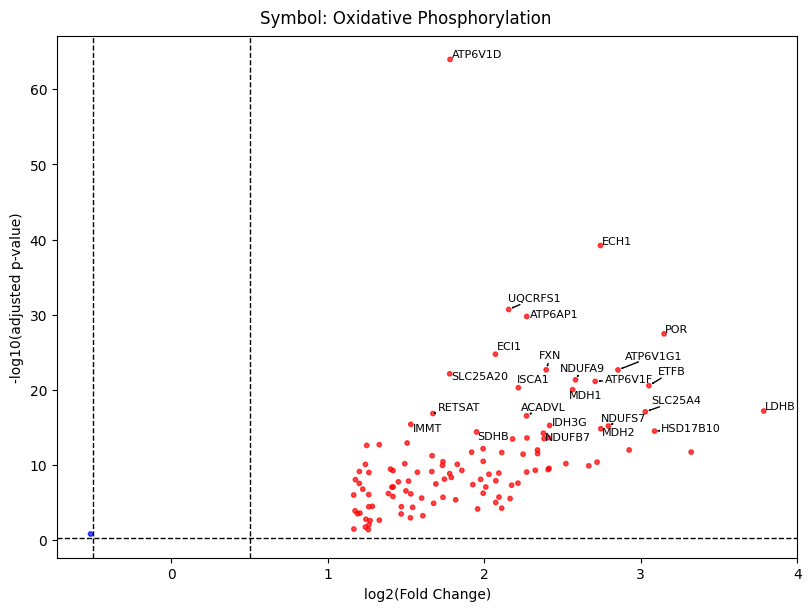

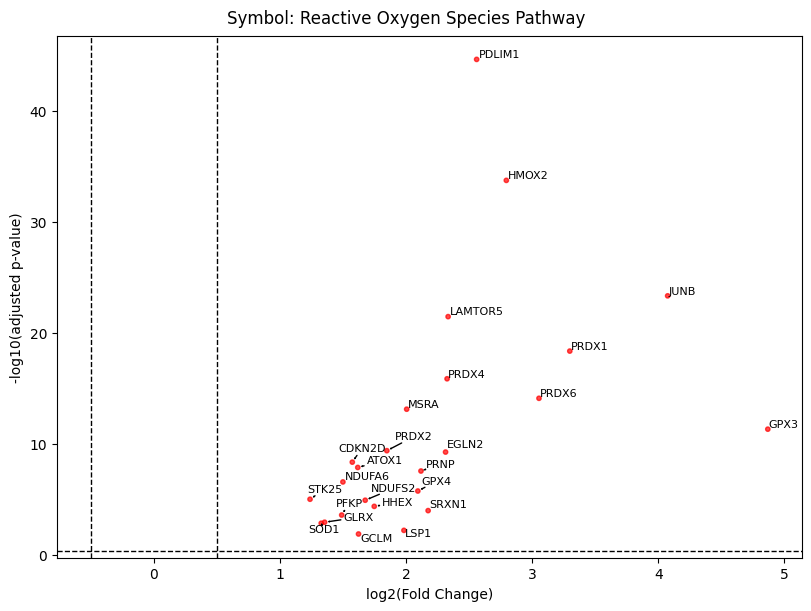

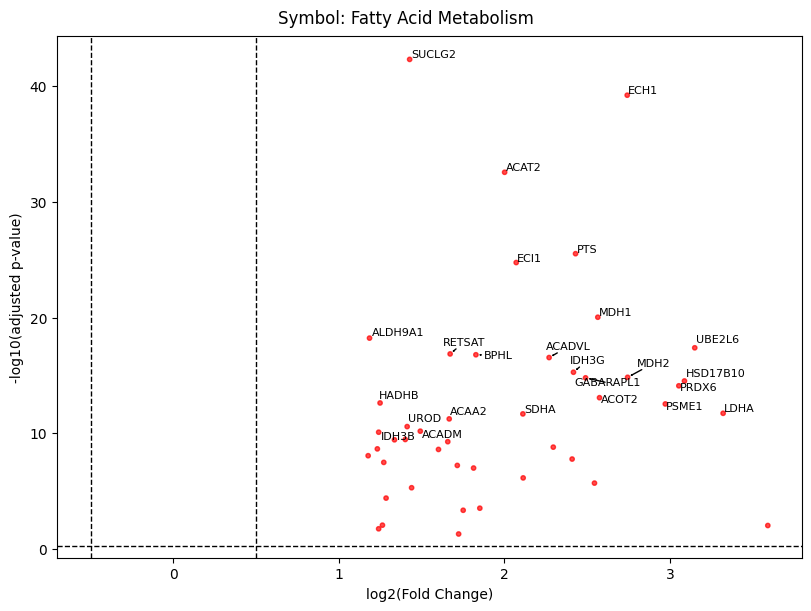

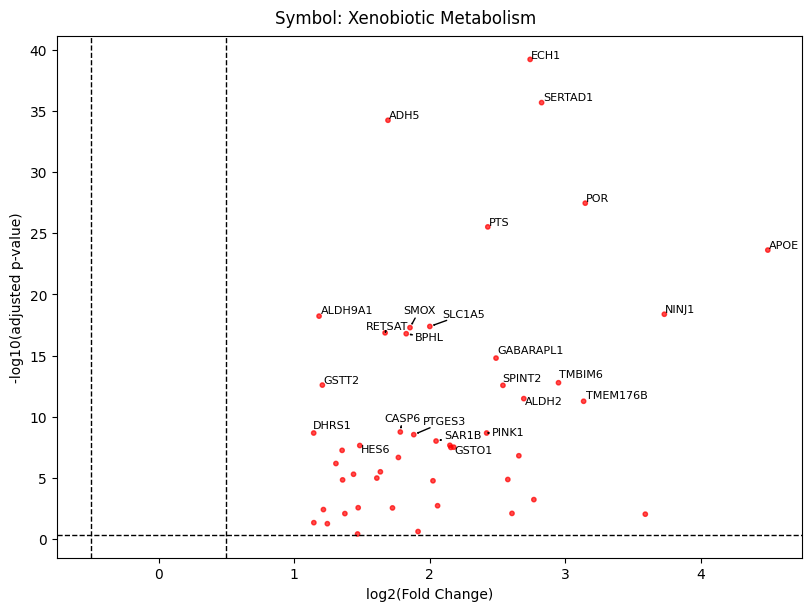

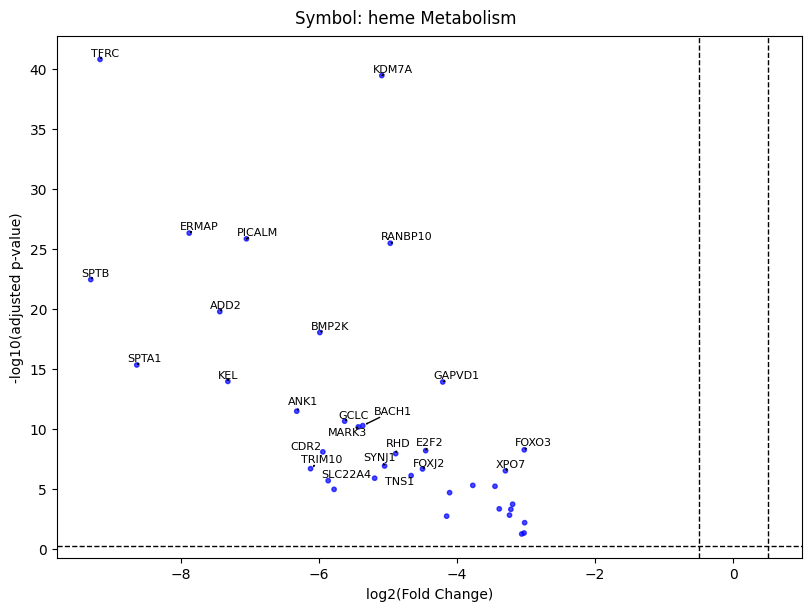

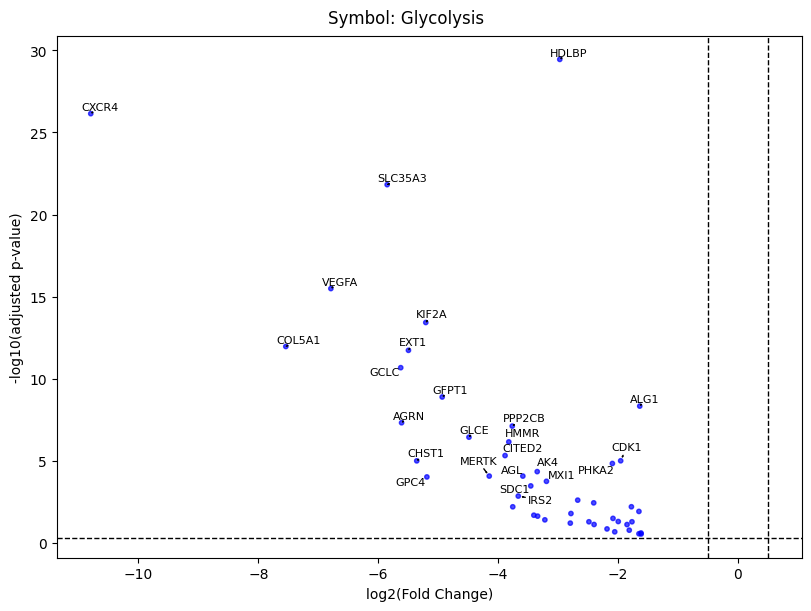

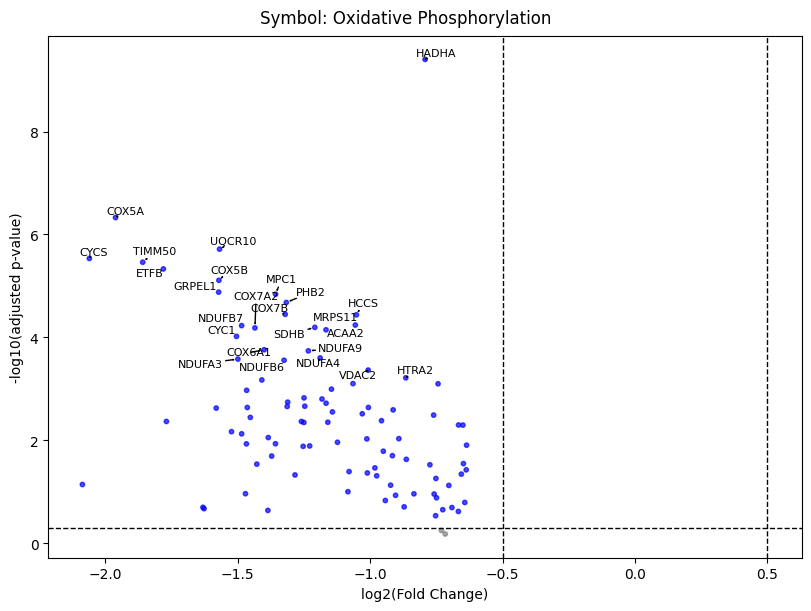

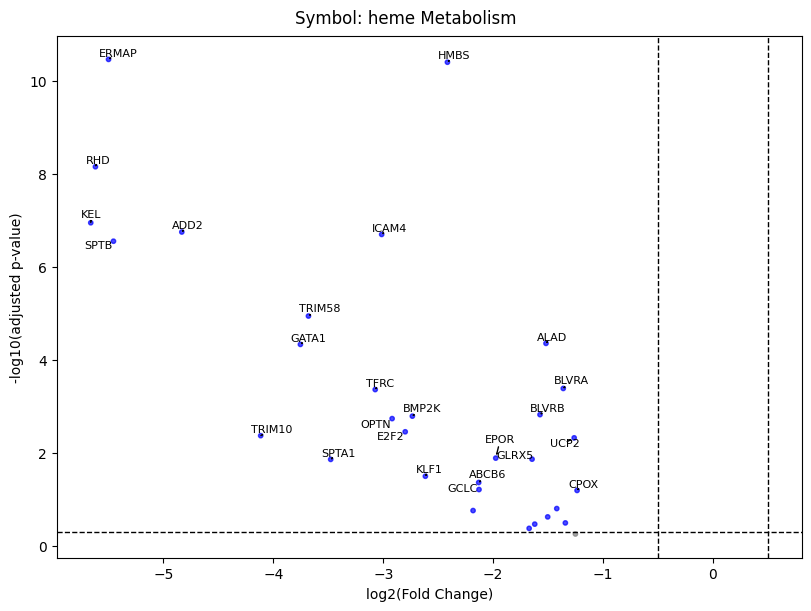

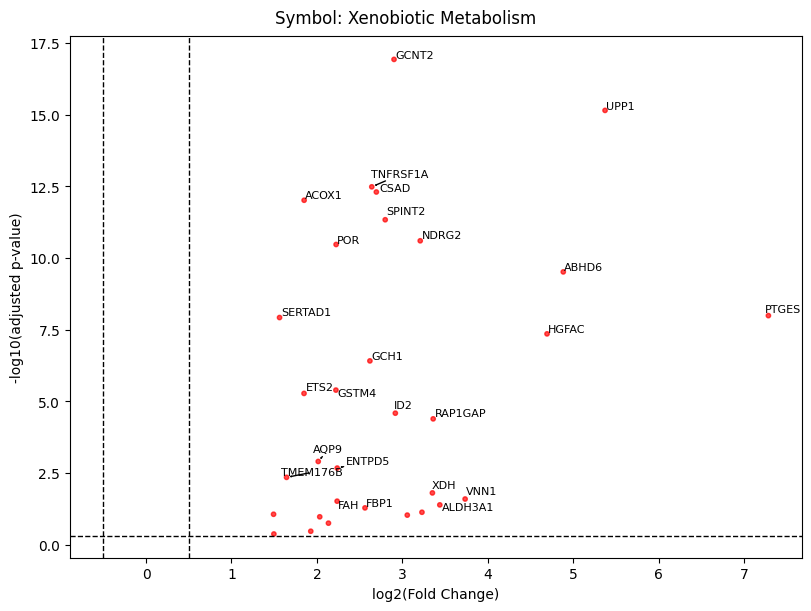

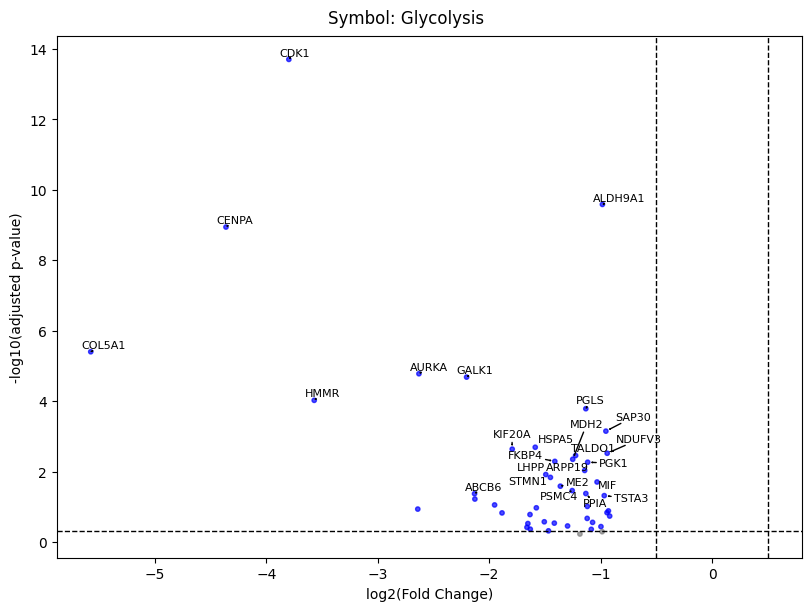

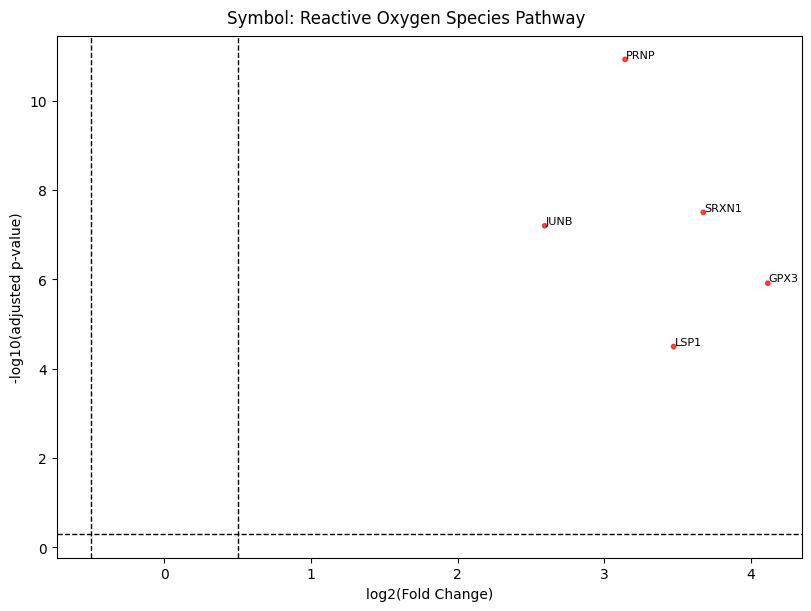

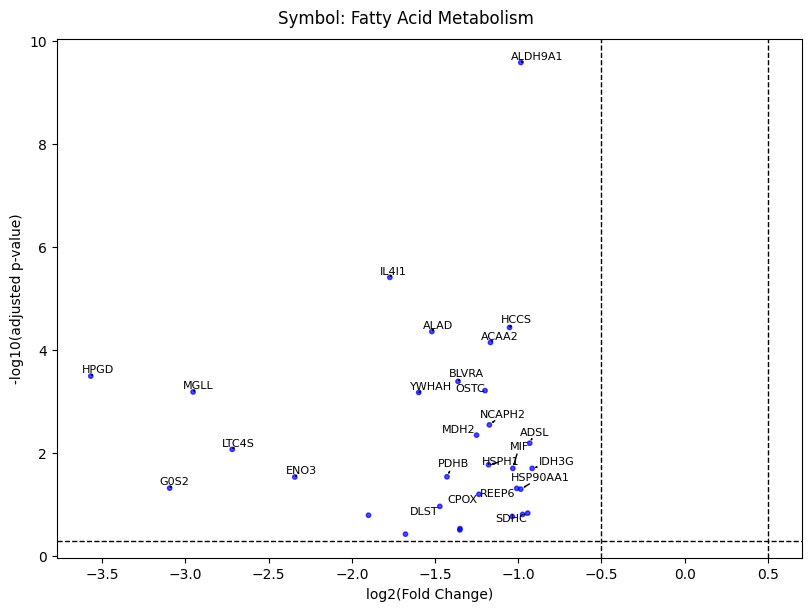

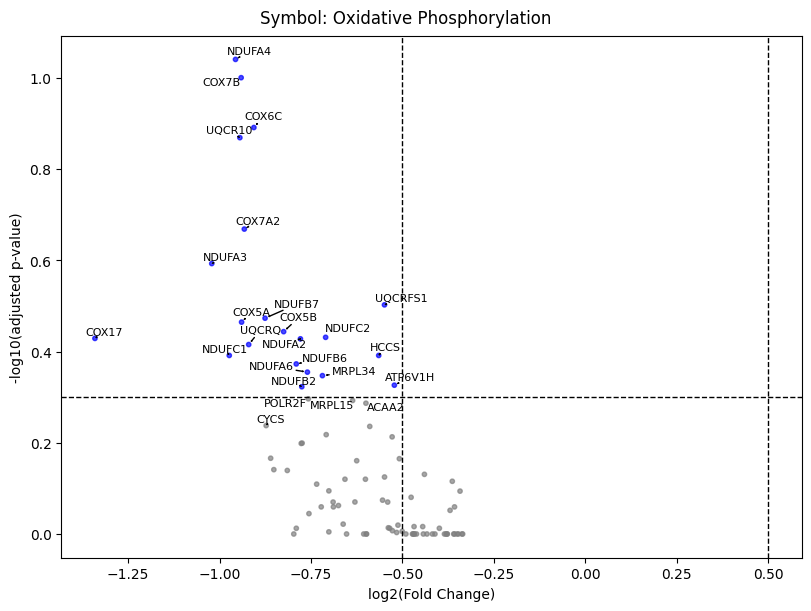

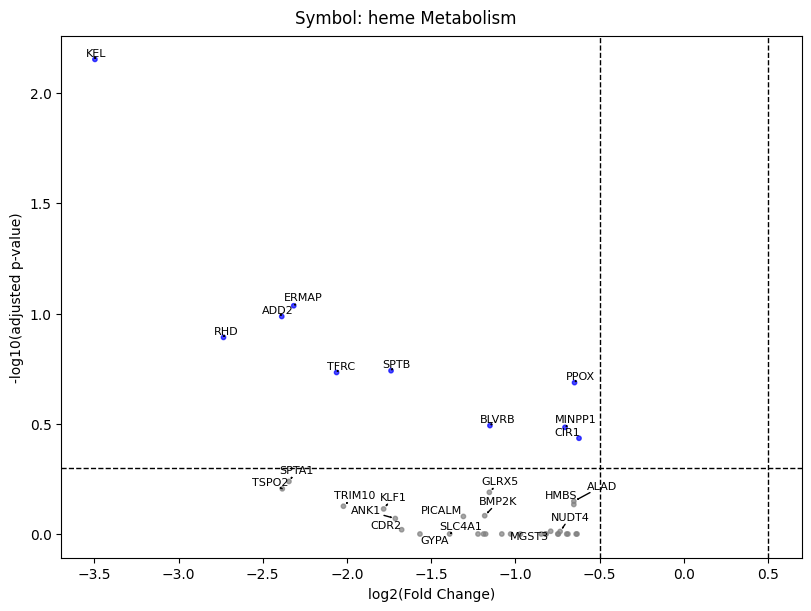

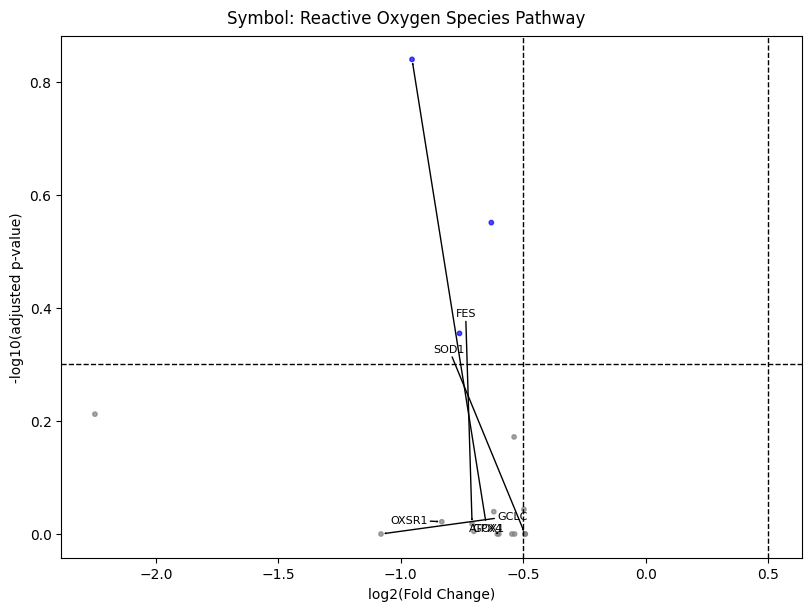

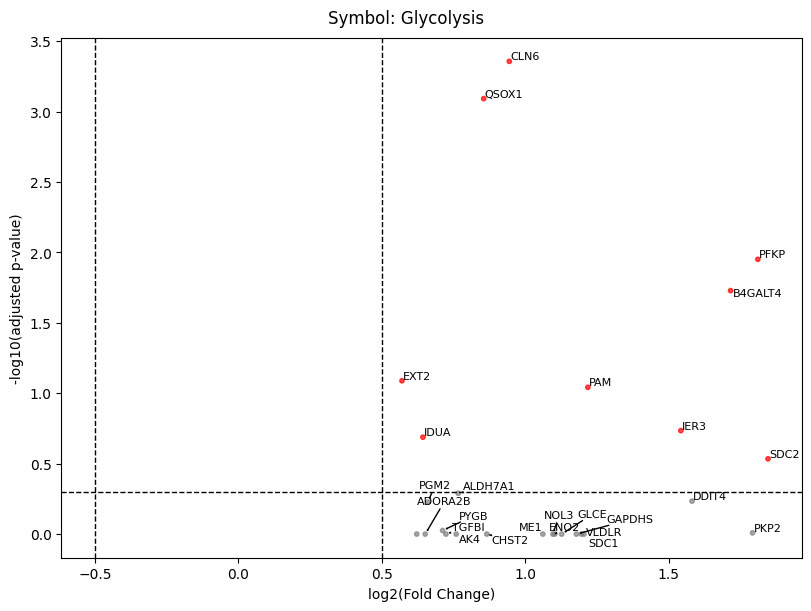

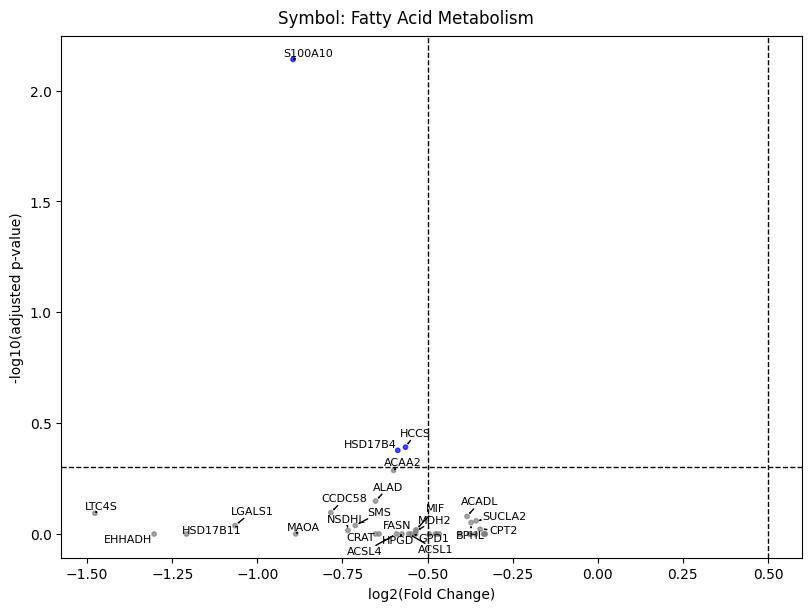

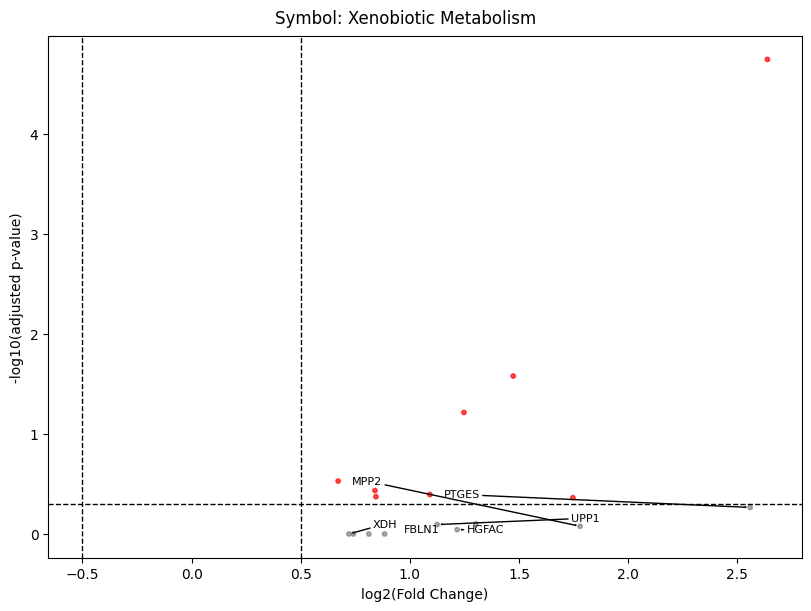

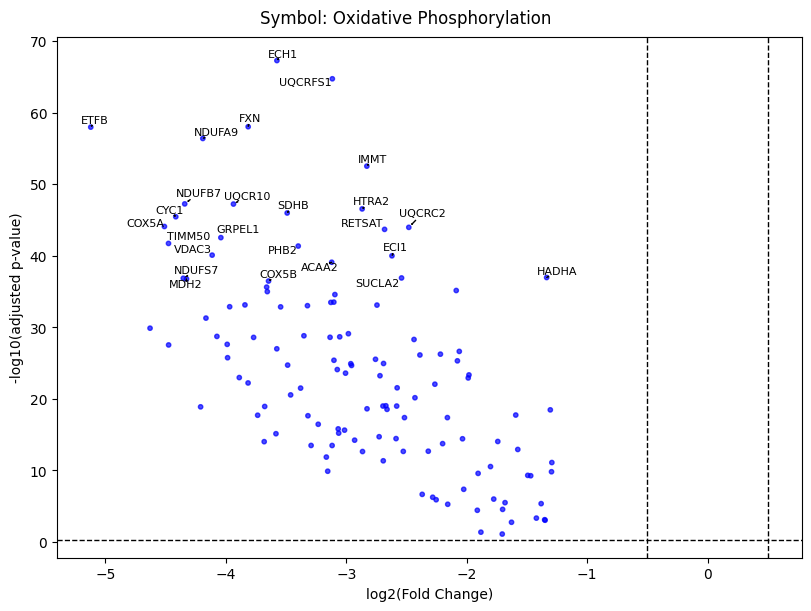

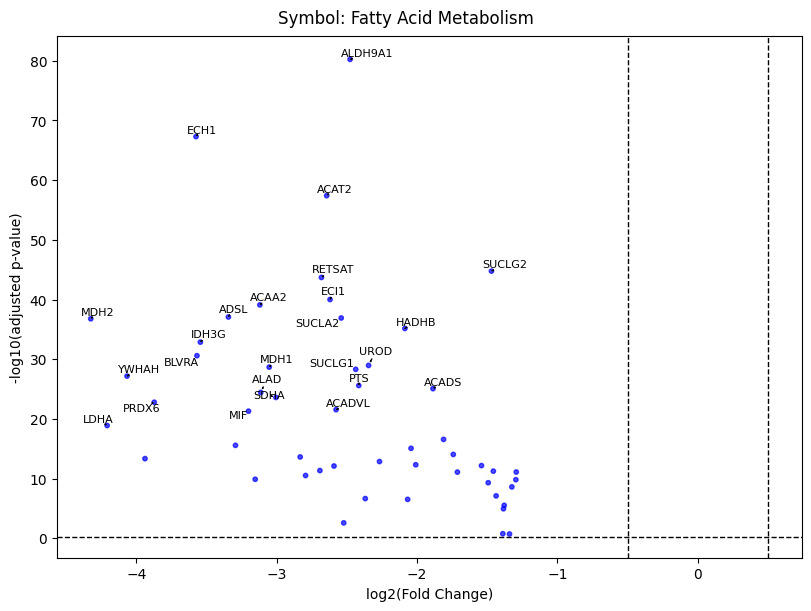

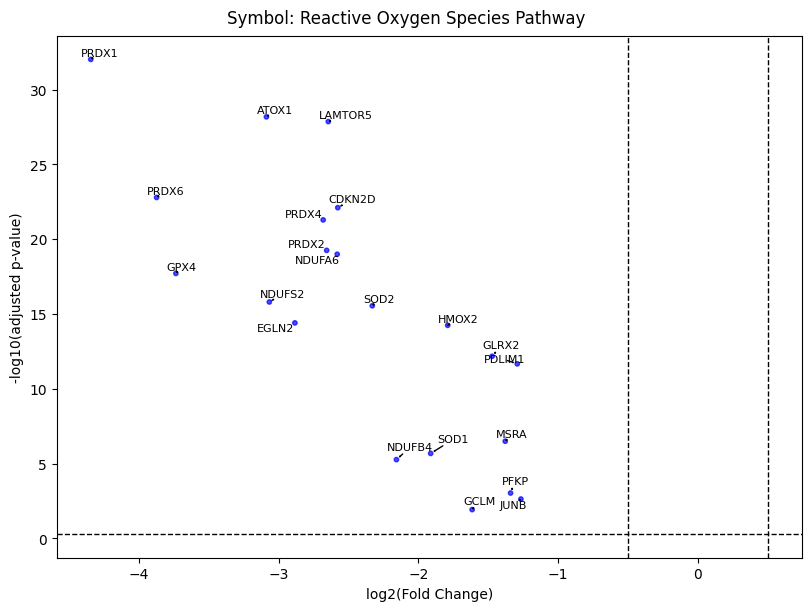

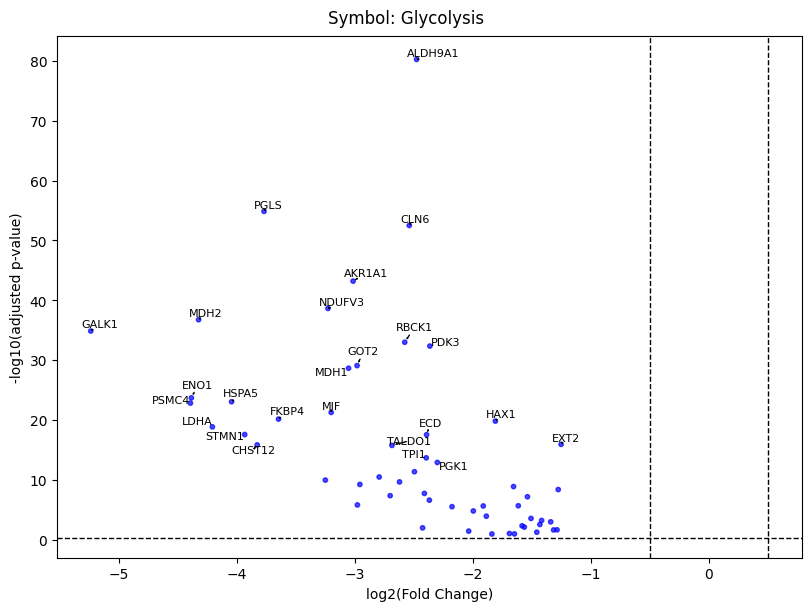

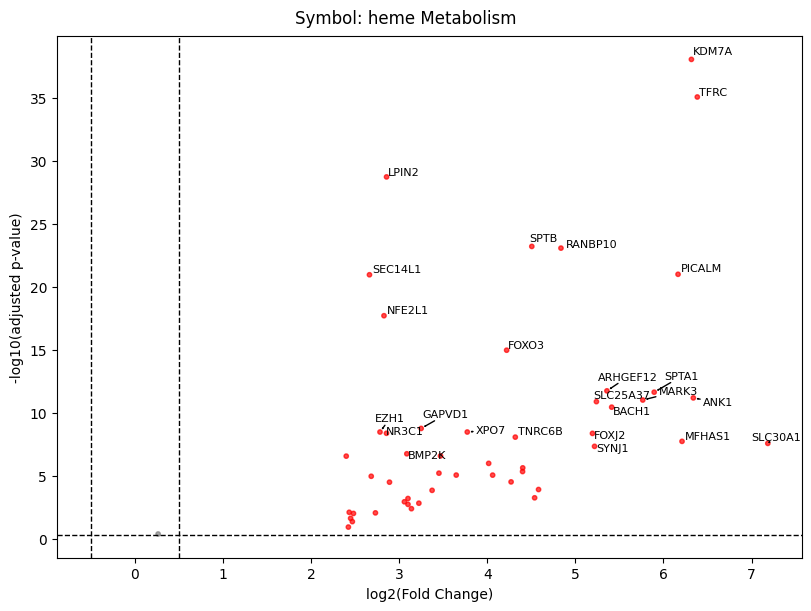

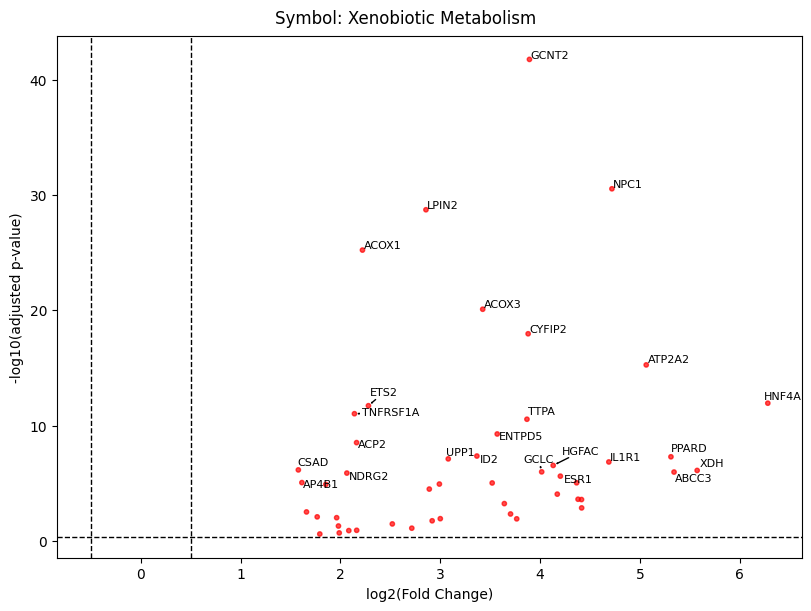

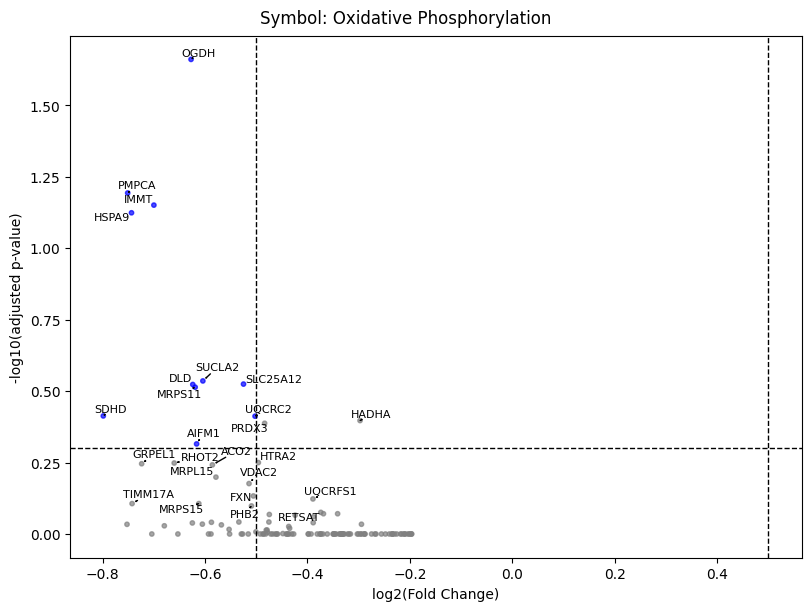

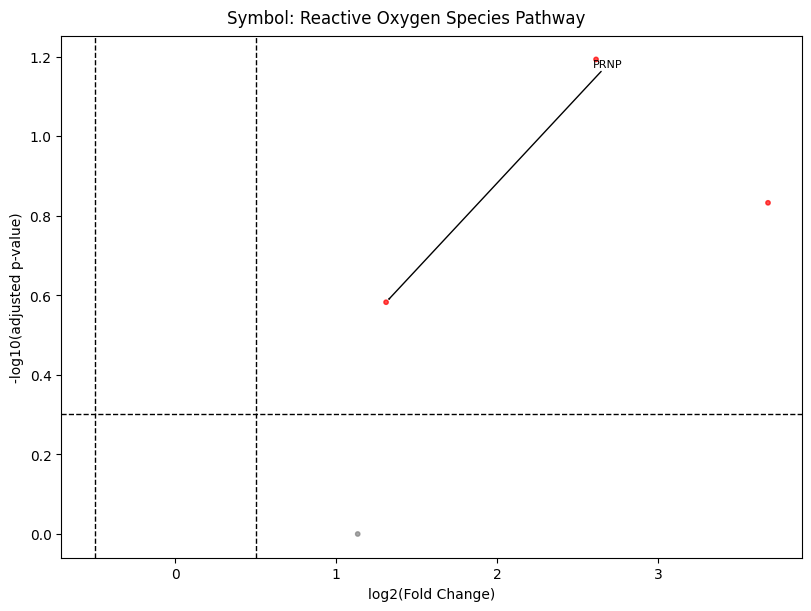

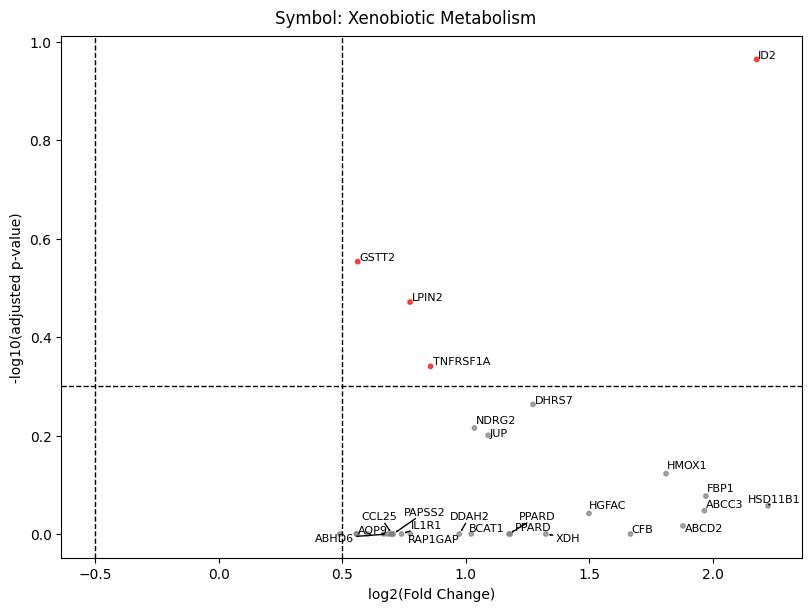

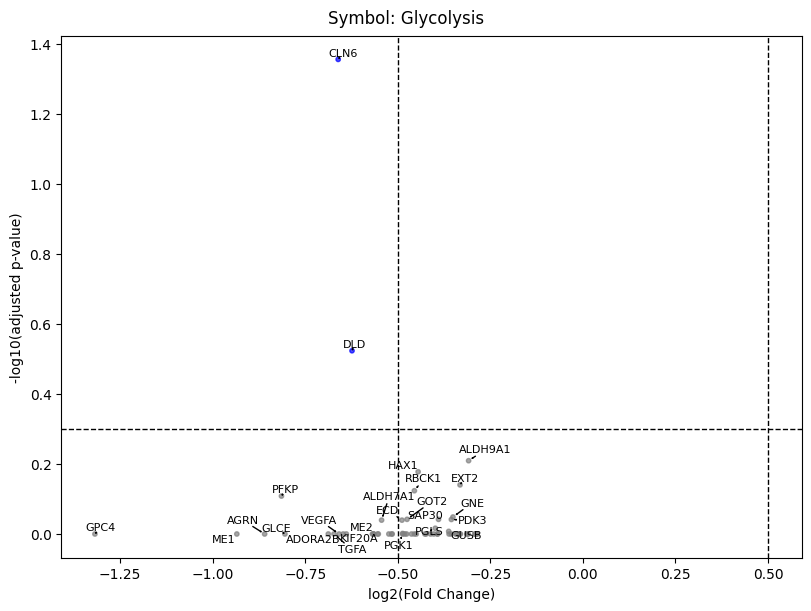

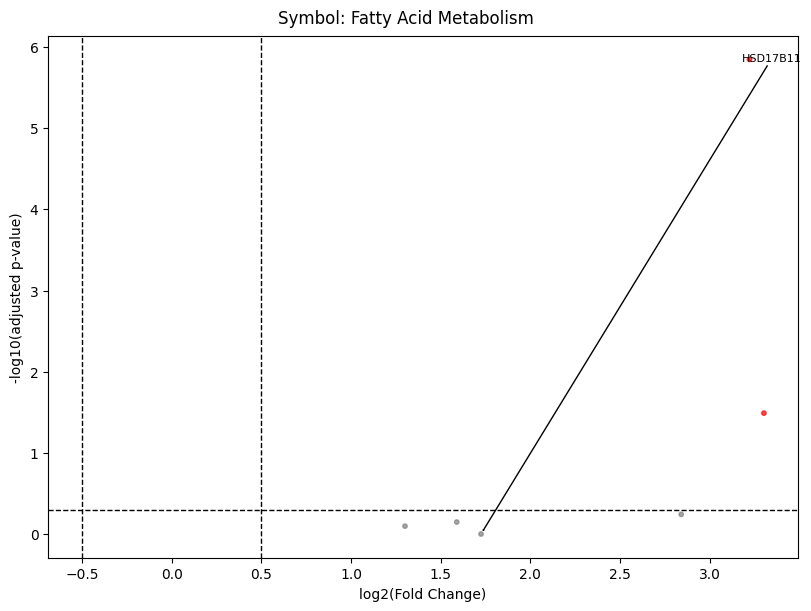

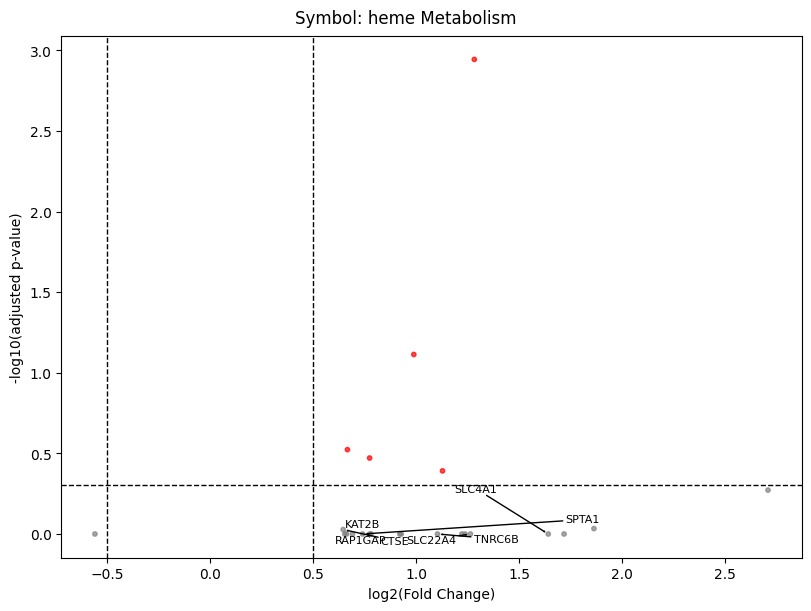

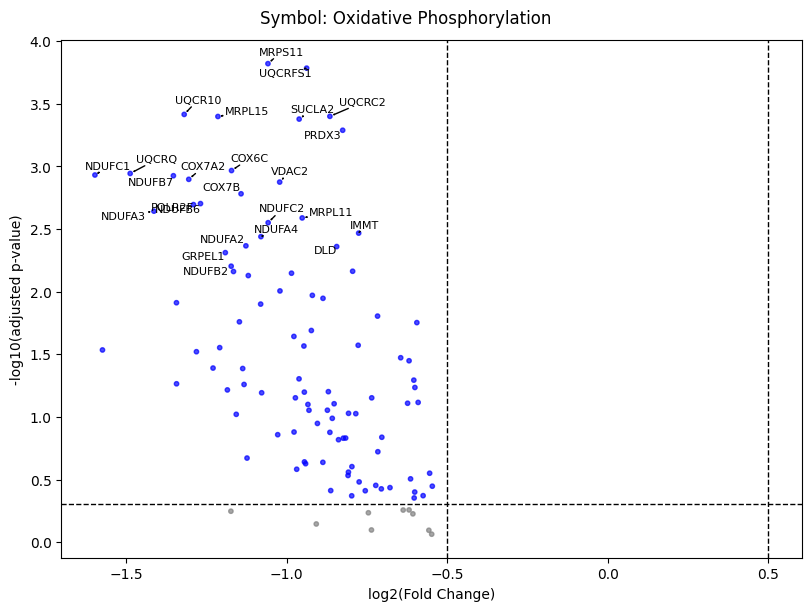

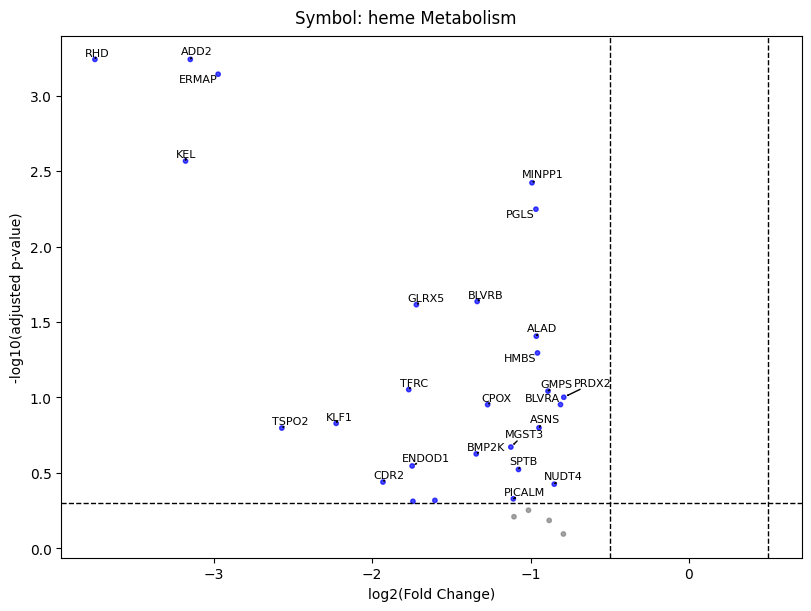

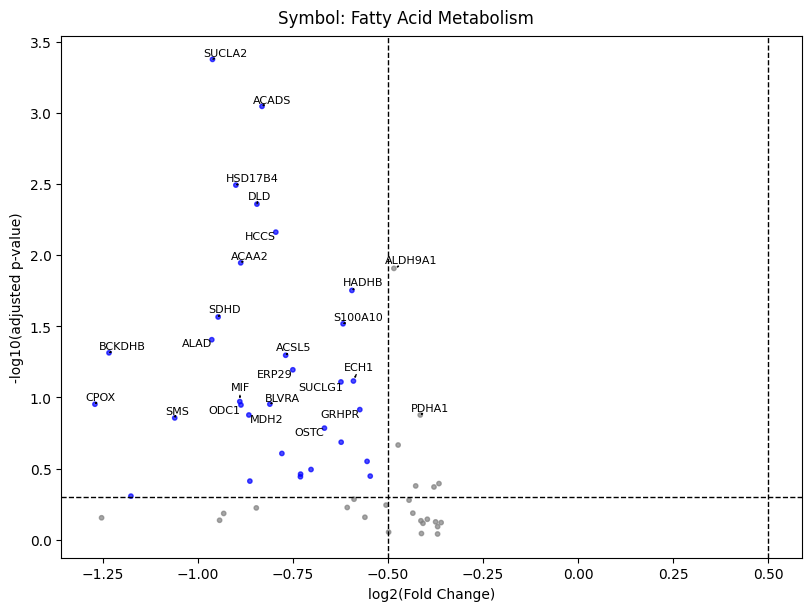

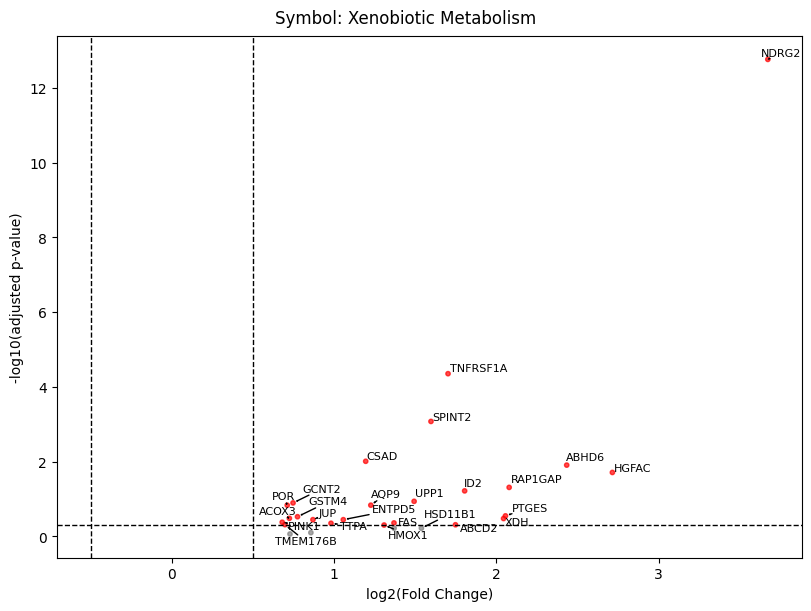

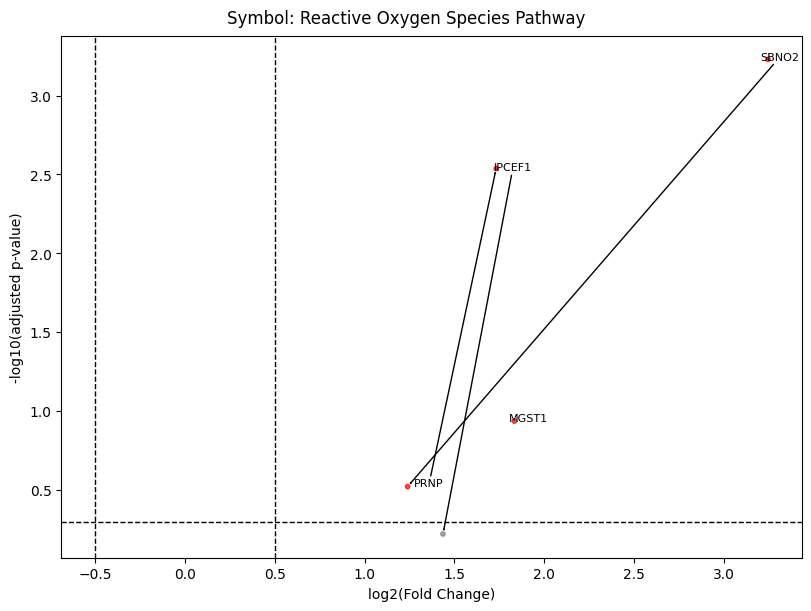

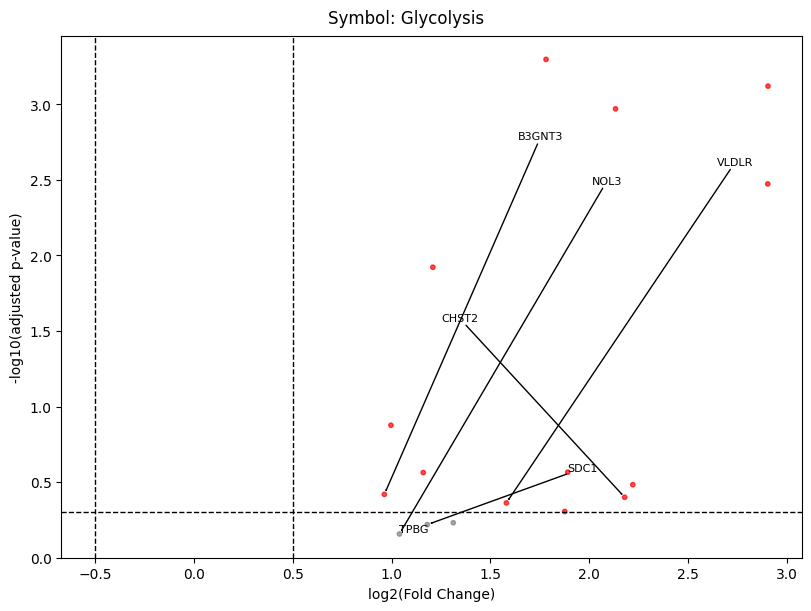

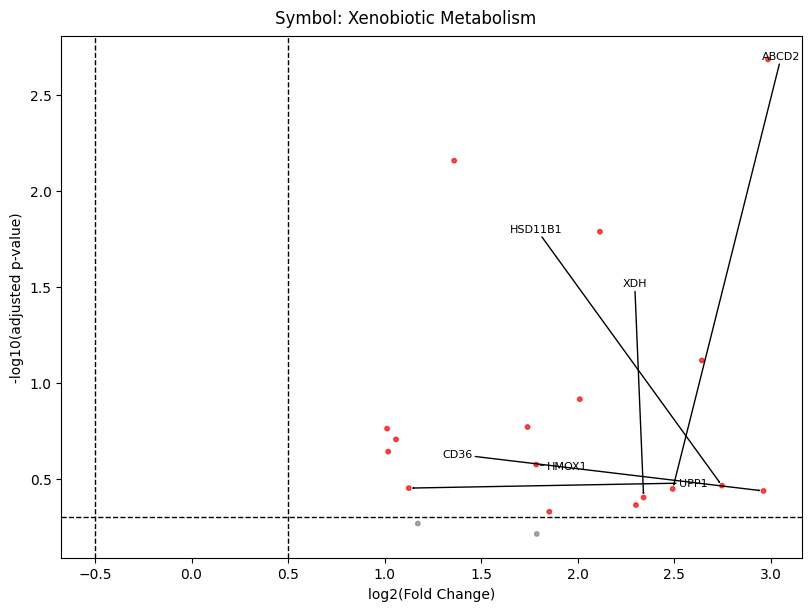

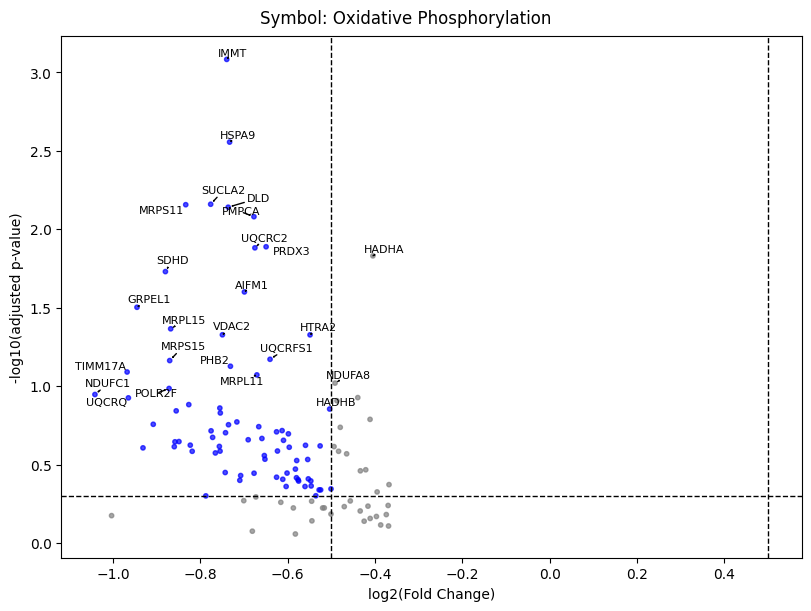

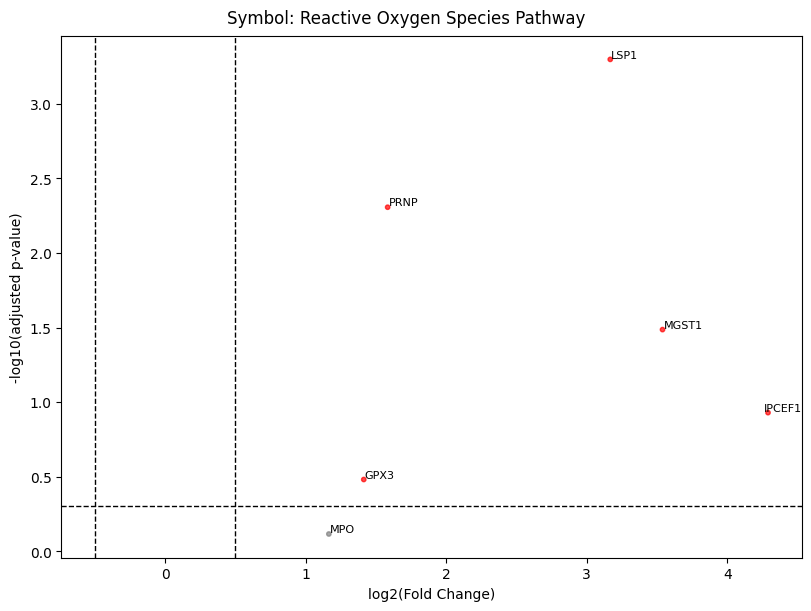

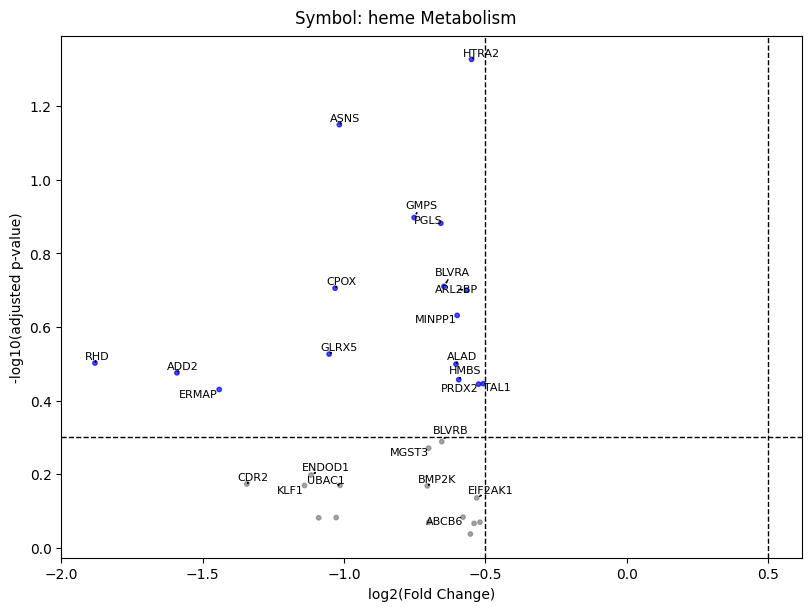

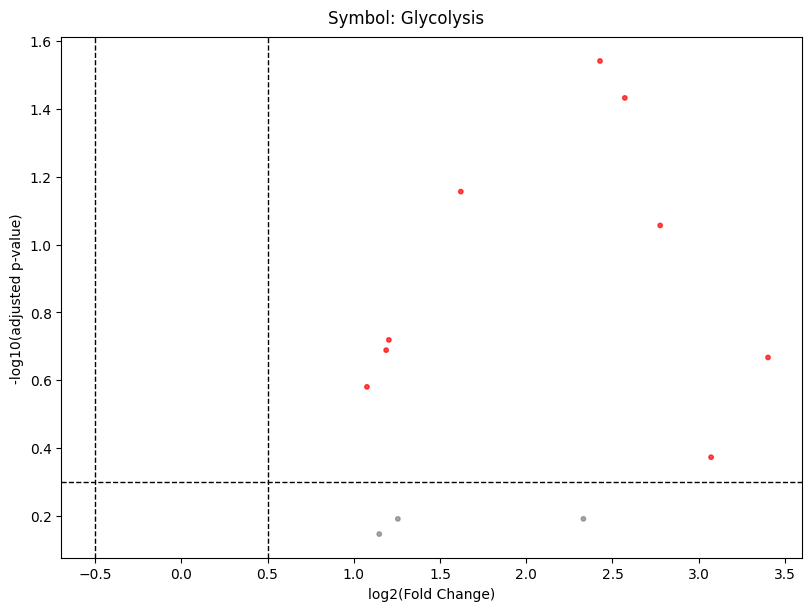

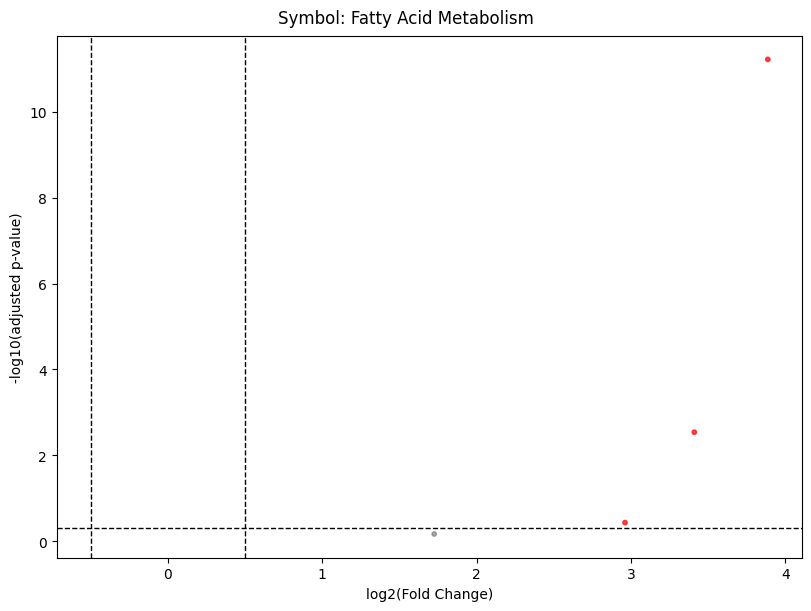

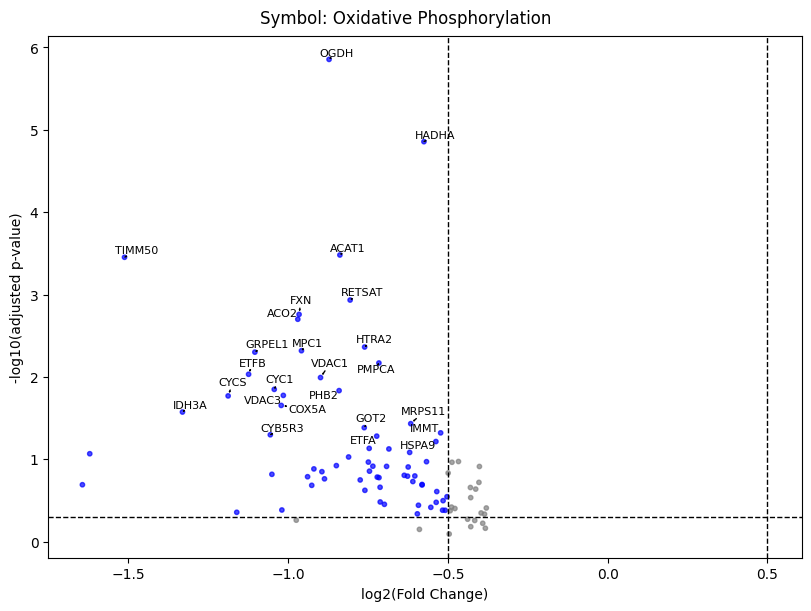

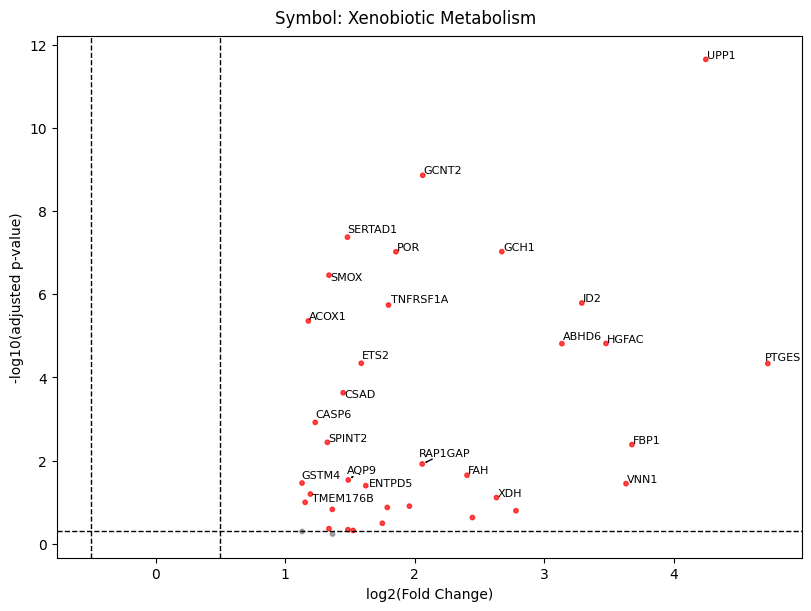

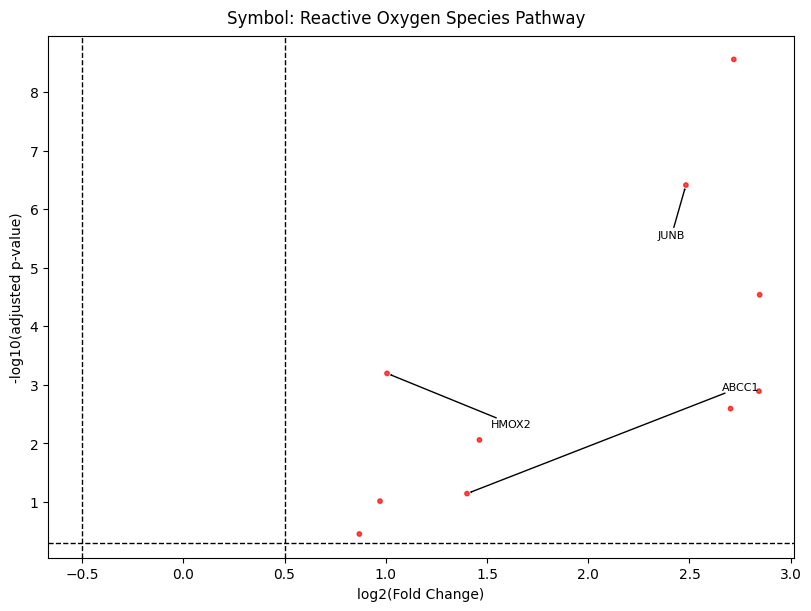

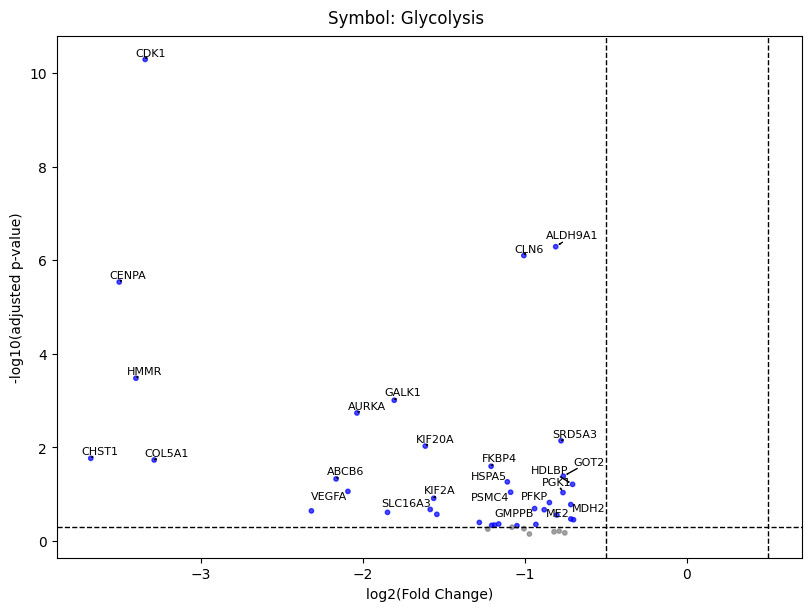

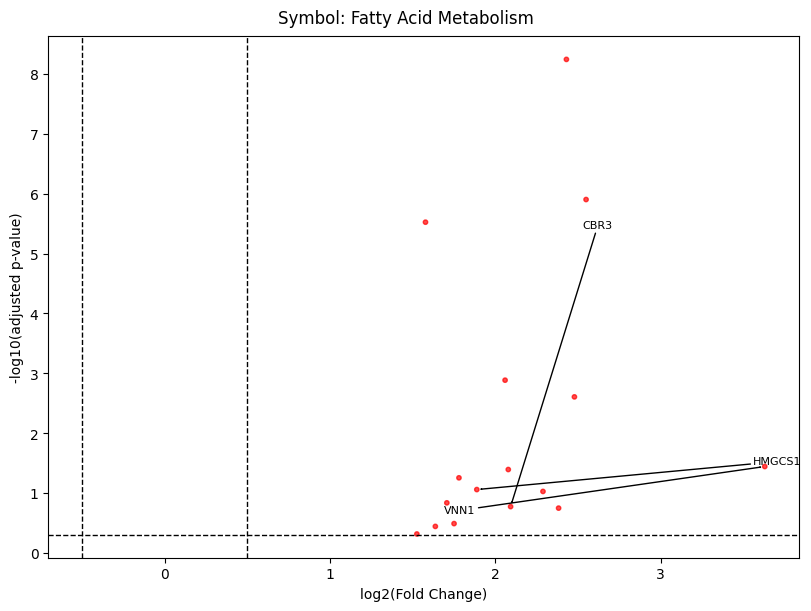

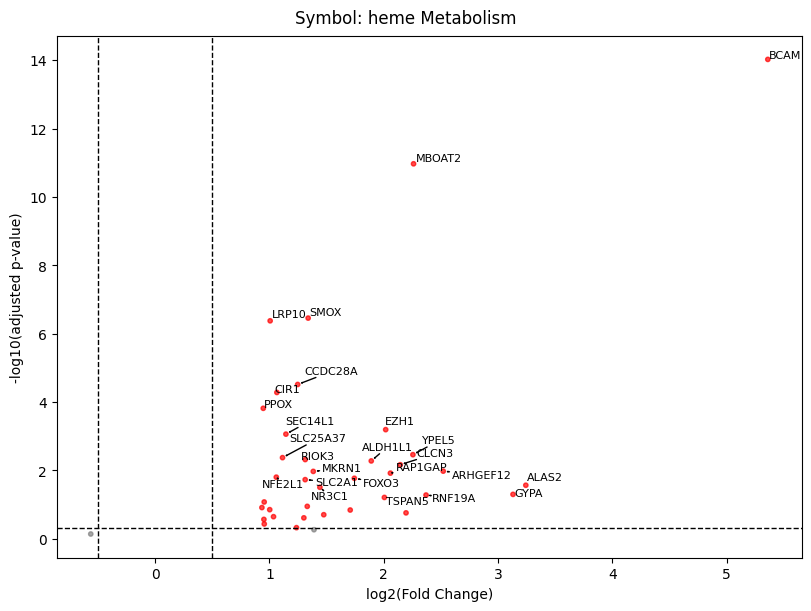

In [191]:
# create GSEA / volcano plots

for fp in DEG_FILEPATHS:
    df = preprocess_deseq_df(deseq_df=pd.read_csv(fp, sep=SEP))

    ranked_list = get_ranked_list(deseq_df=df)

    preranked_gsea = gp.prerank(
        rnk=ranked_list,
        gene_sets="MSigDB_Hallmark_2020",
        threads=8,
        min_size=5,
        max_size=1000,
        permutation_num=1000,
        outdir=None,
        seed=6,
        verbose=True,
    )

    # extract dict of term: list of assoc. genes
    go_terms: dict[str, list[str]] = {
        row["Term"]: row["Lead_genes"].split(";")
        for i, row in preranked_gsea.res2d.iterrows()
    }
    if TERMS_TO_EVALUATE:
        go_terms = {k: v for k, v in go_terms.items() if k in TERMS_TO_EVALUATE}

    # setup paths
    gsea_dir = FIGURES / fp.stem / "gsea-plots"
    gsea_dir.mkdir(parents=True, exist_ok=True)
    volcano_dir = FIGURES / fp.stem / "volcano"
    volcano_dir.mkdir(parents=True, exist_ok=True)

    # create & save GSEA and volcano plots
    for go_term, gene_list in go_terms.items():
        filename = Path(go_term.replace(" ", "-"))

        # GSEA
        preranked_gsea.plot(
            go_term, ofname=str(gsea_dir / filename.with_suffix(".pdf"))
        )

        # Volcano
        volcano_df = preprocess_volcano(
            deseq_df=df,
            gene_set=set(gene_list),
            padj_thresh=THRESH_padj,
            lfc_thresh=THRESH_lfc,
        )
        fig = plot_volcano(
            deseq_df=volcano_df,
            padj_thresh=THRESH_padj,
            lfc_thresh=THRESH_lfc,
            symbol=go_term,
            top_n_genes=TOP_N_GENES,
            save=volcano_dir / filename.with_suffix(".png"),
            show=False,
        )

    # make joint gsea plot
    preranked_gsea.plot(
        terms=TERMS_TO_EVALUATE, figsize=(5, 4), ofname=str(gsea_dir / "all-terms.pdf")
    )